In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression, LinearRegression
from matplotlib.colors import ListedColormap
import random

# np.random.seed(3498734)

In [2]:
def jitter(arr):
    return arr + np.random.randn(len(arr)) * .02

In [3]:
# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
df = mci.copy()
df = df.rename(columns={'CSF Amyloid (pg/mL)': 'amyloid', 'CSF Phosphorylated tau (pg/mL)': 'tau', "Progression to Alzheimer's Disease" : 'progression'})
numeric_cols = ['Age', 'MMSE', 'amyloid', 'CSF Total tau (pg/mL)','tau']
# 5. Final feature set + target
feature_cols = numeric_cols + ['Sex', 'APOE4']
X = df[feature_cols]
y = df['Target']

### Explore the data

In [4]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,amyloid,CSF Total tau (pg/mL),tau,APOE4,progression,Progression time (months),Target
64,65,Mild Cognitive Impairment,1,69,23,595.0,465.0,75.0,0,No,NaN,0
104,105,Mild Cognitive Impairment,1,70,27,1845.0,353.0,92.4,0,No,NaN,0
105,106,Mild Cognitive Impairment,0,73,29,928.0,531.0,176.0,0,No,NaN,0
106,107,Mild Cognitive Impairment,0,68,23,619.0,477.0,142.0,1,Yes,14.0,1
107,108,Mild Cognitive Impairment,1,78,27,784.0,1231.0,394.0,0,No,NaN,0


In [5]:
df['Target'].value_counts()

Target
1    47
0    42
Name: count, dtype: int64

In [6]:
# already a binary classification target (Progression: Yes/No), no species filtering needed
model_df = df[['amyloid', 'tau', 'Target']].copy()
model_df.head()

,amyloid,tau,Target
64,595.0,75.0,0
104,1845.0,92.4,0
105,928.0,176.0,0
106,619.0,142.0,1
107,784.0,394.0,0


In [7]:
model_df['Target'].value_counts()

Target
1    47
0    42
Name: count, dtype: int64

In [8]:
X = model_df[['tau']]
y = model_df['Target']

In [9]:
near_zeros_p = jitter(np.zeros(len(y)))
near_zeros = jitter(np.zeros((y==0).sum()))
near_ones = jitter(np.ones((y==1).sum()))

In [10]:
from sklearn.linear_model import LogisticRegression

In [11]:
lr = LogisticRegression().fit(X,y.values.ravel())

In [12]:
lr_beta0 = lr.intercept_[0]

In [13]:
lr_beta1 = lr.coef_[0,0]

In [14]:
lr_thresh = -lr_beta0/lr_beta1

In [15]:
(lr_beta0, lr_beta1, lr_thresh)

(np.float64(-0.5373266332161268),
 np.float64(0.009012346195961494),
 np.float64(59.621170950679556))

threshold is printed above (in pg/mL) # patients with tau above this value are classified as likely to progress to Alzheimer's Disease, below that as not progressing


In [16]:
X1 = X[y==0].to_numpy()
X2 = X[y==1].to_numpy()

mu1 = np.mean(X1)
mu2 = np.mean(X2)

var1 = np.var(X1)
var2 = np.var(X2)

var = np.mean((var1,var2))

#coefficients
ax_beta0 = (mu1**2 - mu2**2)/2/var
ax_beta1 = (mu2-mu1)/var
ax_thresh = -ax_beta0/ax_beta1

(ax_beta0, ax_beta1, ax_thresh)

(np.float64(-0.4386240110438863),
 np.float64(0.005774719292346762),
 np.float64(75.95590172239106))

In [17]:
def sigmoid(beta0, beta1, x):
    return 1/(1 + np.exp(-beta0 - beta1*x))

In [18]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

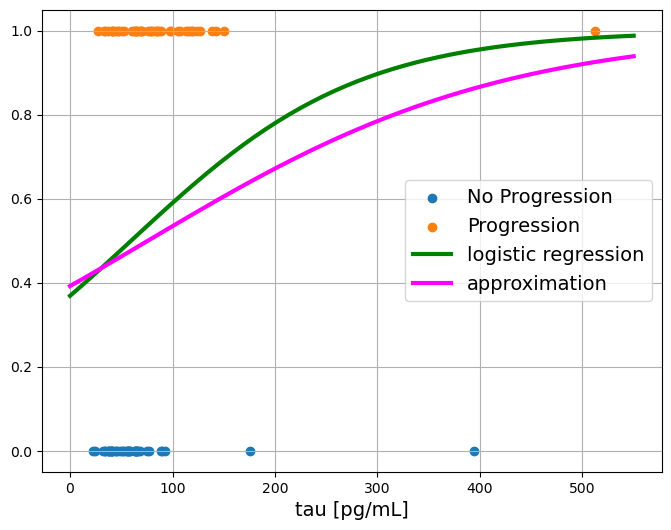

In [19]:
x = np.linspace(0, 550)
plt.figure(figsize=(8,6))
plt.scatter(X1, np.zeros(len(X1)), label='No Progression')
plt.scatter(X2, np.ones(len(X2)), label='Progression')
plt.plot(x, sigmoid(lr_beta0, lr_beta1, x), linewidth=3, color='green', label='logistic regression')
plt.plot(x, sigmoid(ax_beta0, ax_beta1, x), linewidth=3, color='magenta', label='approximation')
plt.legend(fontsize=14)
plt.xlabel('tau [pg/mL]', fontsize=14)
plt.grid()
plt.show()

## plot tau for progression vs. no progression

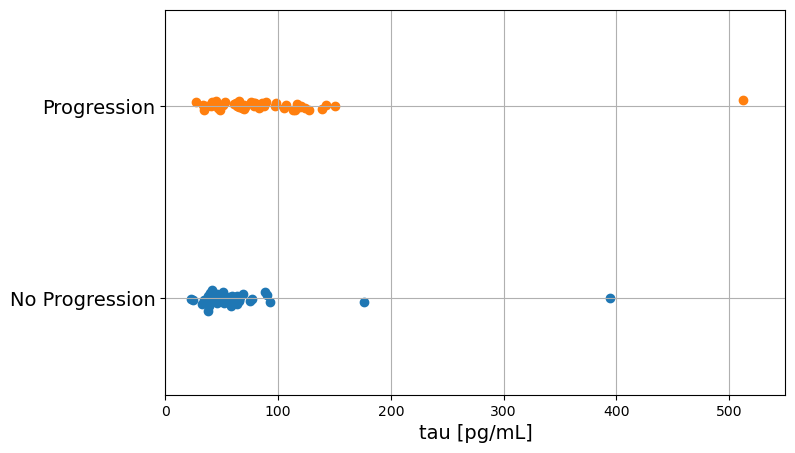

In [20]:
plt.figure(figsize=(8,5))
ax = plt.axes()
plt.scatter( model_df.tau[model_df.Target==0], near_zeros, label='No Progression' )
plt.scatter( model_df.tau[model_df.Target==1], near_ones, label='Progression' )
plt.ylim((-0.5,1.5))
plt.xlim((0,550))
ax.set_yticks((0,1))
ax.set_yticklabels(['No Progression','Progression'],fontsize=14)
plt.xlabel('tau [pg/mL]',fontsize=14)
plt.grid()

## rebuild class arrays for outlier demo

In [21]:
X = np.expand_dims( model_df['tau'].values, axis=1 )
y = model_df['Target'].values

X0 = X[y==0]
y0 = y[y==0]
X1 = X[y==1]
y1 = y[y==1]

## 2class, 1input linear regression

Threshold = 56.21751187214712


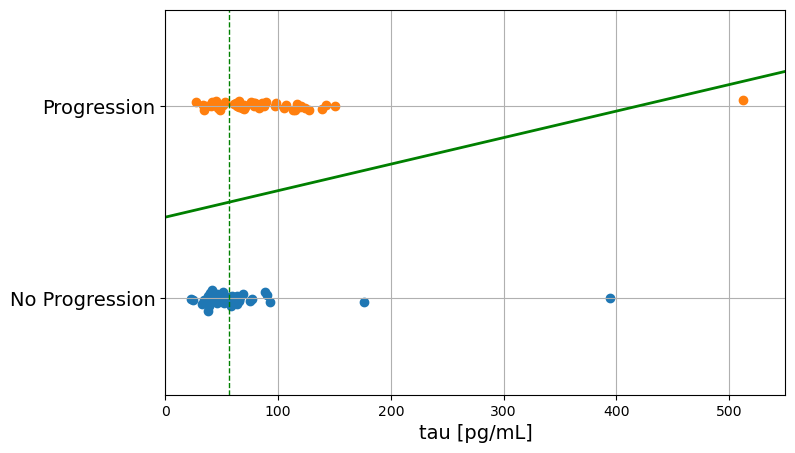

In [22]:
linreg = LinearRegression().fit(X, y)
linreg_thresh = (0.5 - linreg.intercept_)/linreg.coef_[0]

print("Threshold = " + str(linreg_thresh))

# plot
xlim  = (0, 550)
pl = np.expand_dims( np.linspace(xlim[0],xlim[1]), axis=1 )
plt.figure(figsize=(8,5))
ax = plt.axes()
plt.vlines(linreg_thresh, -0.5, 1.5, colors='green',linestyle='--', linewidth=1)
plt.scatter( X0, near_zeros, label='No Progression' )
plt.scatter( X1, near_ones, label='Progression' )
plt.plot(pl, linreg.predict(pl),color='green',linewidth=2) 
plt.xlim(xlim)
plt.ylim((-0.5,1.5))
ax.set_yticks((0,1))
ax.set_yticklabels(['No Progression','Progression'],fontsize=14)
plt.xlabel('tau [pg/mL]',fontsize=14)
plt.grid()

## add an outlier, do linear regression


In [23]:
Xo = np.expand_dims( np.append(X,1200), axis=1 )
yo = np.append(y, 1)
Xo0 = Xo[yo==0]
Xo1 = Xo[yo==1]

Threshold = 37.32972368245417


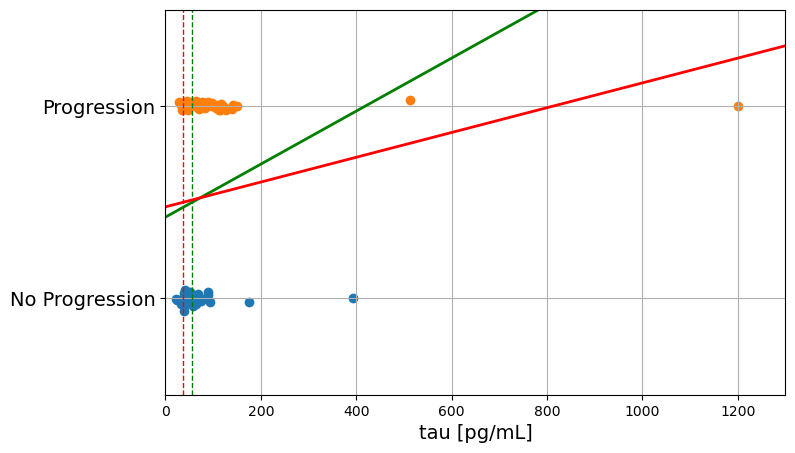

In [24]:
linrego = LinearRegression().fit(Xo, yo)
linreg_thresho = (0.5 - linrego.intercept_)/linrego.coef_[0]

print("Threshold = " + str(linreg_thresho))

xlim = (0, 1300)
pl = np.expand_dims( np.linspace(xlim[0],xlim[1]), axis=1 )


plt.figure(figsize=(8,5))
ax = plt.axes()
plt.vlines(linreg_thresh, -0.5, 1.5, colors='green',linestyle='--', linewidth=1)
plt.vlines(linreg_thresho, -0.5, 1.5, colors='red',linestyle='--', linewidth=1)
plt.scatter( Xo0, near_zeros, label='No Progression' )
plt.scatter( Xo1, np.append(near_ones,1), label='Progression' )
plt.plot(pl, linreg.predict(pl),color='green',linewidth=2)
plt.plot(pl, linrego.predict(pl),color='red',linewidth=2)
plt.xlim(xlim)
plt.ylim((-0.5,1.5))
ax.set_yticks((0,1))
ax.set_yticklabels(['No Progression','Progression'],fontsize=14)
plt.xlabel('tau [pg/mL]',fontsize=14)
plt.grid()

In [25]:
# logistic regression
logreg = LogisticRegression().fit(X, y)
logrego = LogisticRegression().fit(Xo, yo)

logreg_thresh = -logreg.intercept_/logreg.coef_[0]
logreg_thresho = -logrego.intercept_/logrego.coef_[0]

d_log_thresh = logreg_thresh-logreg_thresho
d_lin_thresh = linreg_thresh-linreg_thresho

d_lin_thresh / d_log_thresh

array([-16052.88461903])

# VIDEO 2 ...

### MAKE THE BINNING PICTURE

In [26]:
model_df['tau']
model_df['Target']

64     0
104    0
105    0
106    1
107    0
      ..
187    0
188    1
189    0
190    1
191    1
Name: Target, Length: 89, dtype: int64

### OVERLAP GAUSSIAN CURVES

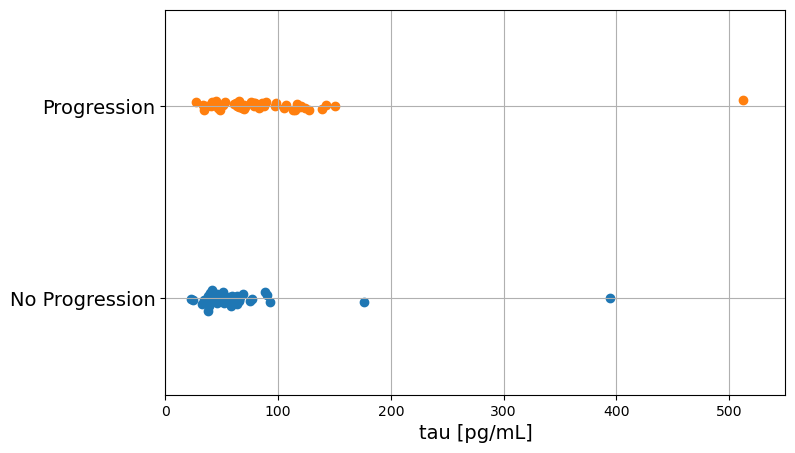

In [27]:
plt.figure(figsize=(8,5))
ax = plt.axes()
plt.scatter( model_df.tau[model_df.Target==0], near_zeros, label='No Progression' )
plt.scatter( model_df.tau[model_df.Target==1], near_ones, label='Progression' )
plt.ylim((-0.5,1.5))
plt.xlim((0,550))
ax.set_yticks((0,1))
ax.set_yticklabels(['No Progression','Progression'],fontsize=14)
plt.xlabel('tau [pg/mL]',fontsize=14)
plt.grid()

# -------------------------------------------------------

Text(0, 0.5, 'amyloid [pg/mL]')

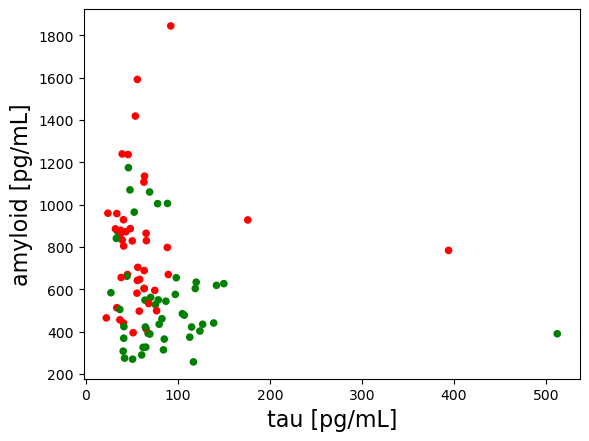

In [28]:
colors = {0:'red', 1:'green'}
a = model_df.plot(kind='scatter',x='tau',y='amyloid',c=model_df['Target'].map(colors))
a.set_xlabel('tau [pg/mL]',fontsize=16)
a.set_ylabel('amyloid [pg/mL]',fontsize=16)

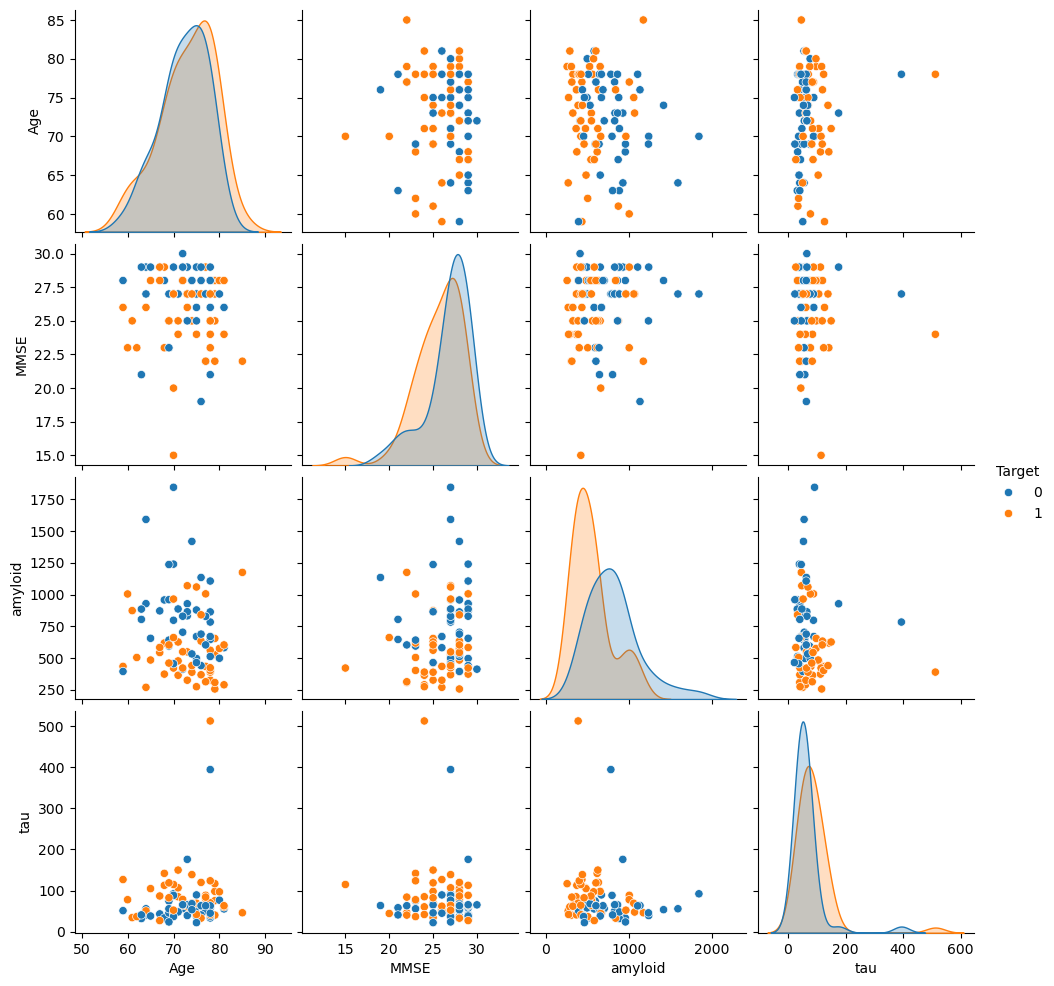

In [29]:
sns.pairplot(df[['Age','MMSE','amyloid','tau','Target']], hue='Target')

# PLOTTIG DECISION BOUNDARIES (FROM JOSH)

/home/fazuskazoo/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


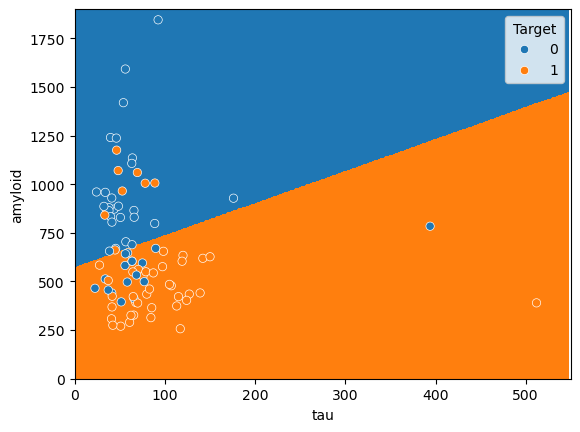

In [30]:
logistic_regression_model = LogisticRegression()
logistic_regression_model = logistic_regression_model.fit(df[["tau", "amyloid"]], df["Target"])


sns_cmap = ListedColormap(np.array(sns.color_palette())[0:2, :])

xx, yy = np.meshgrid(np.arange(0, 550, 2),
                     np.arange(0, 1900, 5))


Z_string = logistic_regression_model.predict(np.c_[xx.ravel(), yy.ravel()])
categories, Z_int = np.unique(Z_string, return_inverse=True)
Z_int = Z_int 
Z_int = Z_int.reshape(xx.shape)
cs = plt.contourf(xx, yy, Z_int, cmap=sns_cmap)
sns.scatterplot(data = df, x = "tau", y="amyloid", hue="Target")
plt.xlim(0, 550);
plt.ylim(0, 1900);
plt.savefig("images/decision_boundary.png", dpi=300, bbox_inches = "tight")